# Aggregrations and Filtering

In this section, you will learn how to compute differentially private statistics while applying key data manipulation techniques such as: 

- Singular Variable `group_by`
- Multiple Variable `group_by`
- Filtering

For each method, we will compare the actual values to the computed differentially private values to demonstrate utility. The [documentation](https://docs.opendp.org/en/nightly/api/python/opendp.polars.html#module-opendp.polars) provides more information about the methods. We will use the [sample data](https://github.com/opendp/dp-test-datasets/blob/master/data/sample_FR_LFS.csv.zip) from the Labour Force Survey in France. 

## Set Up

In [1]:
import polars as pl 
import opendp.prelude as dp
import seaborn as sns 
import matplotlib.pyplot as plt

dp.enable_features("contrib")
sns.set_theme(style='darkgrid')

In [2]:
![ -e sample_FR_LFS.csv ] || ( curl 'https://github.com/opendp/dp-test-datasets/blob/master/data/sample_FR_LFS.csv.zip?raw=true' --location --output sample_FR_LFS.csv.zip; unzip sample_FR_LFS.csv.zip )

# Many columns contain mixtures of strings and numbers and cannot be parsed as floats,
# so we'll set `ignore_errors` to true to avoid conversion errors.     

# This reads in the sample data. 
df = pl.scan_csv("sample_FR_LFS.csv", ignore_errors=True)

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 5933k  100 5933k    0     0  1030k      0  0:00:05  0:00:05 --:--:-- 1148k3k      0  0:00:06  0:00:03  0:00:03 1141k
Archive:  sample_FR_LFS.csv.zip
  inflating: sample_FR_LFS.csv       
  inflating: __MACOSX/._sample_FR_LFS.csv  


<!-- TODO
For further information on the context parameters, see the introduction for justification. 
-->

In [6]:
estimated_max_partition_len = 60_000_000

context = dp.Context.compositor(
    data=df,
    privacy_unit=dp.unit_of(contributions=36),
    privacy_loss=dp.loss_of(epsilon=1.0),
    split_evenly_over=5,
    margins={
        ("YEAR", ): dp.polars.Margin(public_info= "keys", max_partition_length=estimated_max_partition_len, max_partition_contributions=4),
        ("YEAR", "QUARTER",): dp.polars.Margin(public_info= "keys", max_partition_length=estimated_max_partition_len, max_partition_contributions=1),
        (): dp.polars.Margin(public_info= "lengths",max_partition_length=estimated_max_partition_len, max_num_partitions=1),
    },
)

## Singular Variable *`group_by`* 

To demonstrate the `group_by` method, compute the total number of respondents per year. 

In [4]:
count_year_actual = (
    df.group_by("YEAR").agg(
        pl.len().alias("Actual Count")
    ).sort("YEAR")
).collect()
count_year_actual

YEAR,Actual Count
i64,u32
2004,16491
2005,16460
2006,16291
2007,16838
2008,16774
2009,19998
2010,24081
2011,24776
2012,24952


Now to get the differentially private statistics, add `dp.noise` after the aggregate function is specified and `.release` after the entire query before `.collect`. 

Calling `.release` is always the final step in compiling your differentially private data in a usable form and ensuring it is compliant with differential privacy guarantees. 

*The 'shape' of a dataframe refers to its dimensions, specifically its number of rows and columns.*

In [7]:
count_year_dp = (
    context.query().group_by("YEAR").agg(
        pl.len().dp.noise().alias("DP Count")
    ).sort("YEAR")).release().collect()
count_year_dp

YEAR,DP Count
i64,u32
2004,16092
2005,16473
2006,16284
2007,17611
2008,16781
2009,19764
2010,24471
2011,24474
2012,25040


The following code creates a line graph and illustrates the actual and differentially private counts by year. 

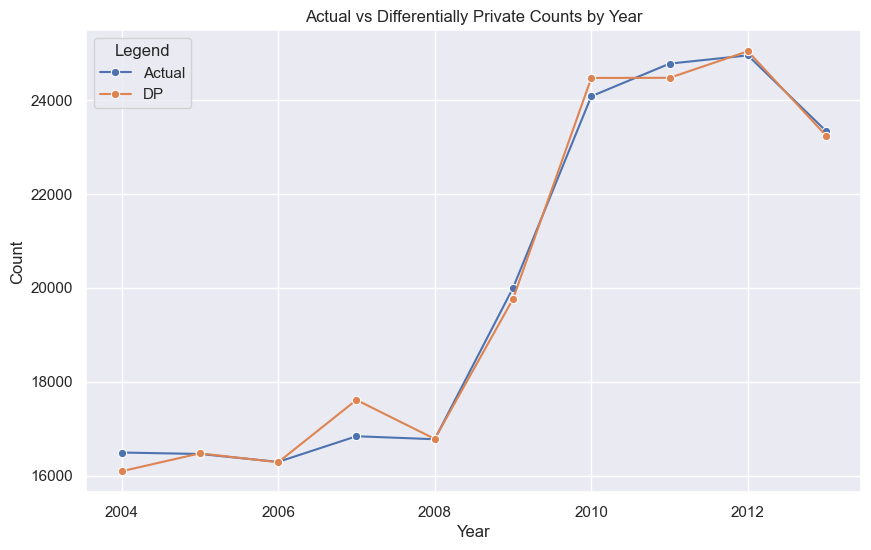

In [8]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=count_year_actual["YEAR"].to_list(), y=count_year_actual["Actual Count"].to_list(), marker="o", label="Actual")
sns.lineplot(x=count_year_dp["YEAR"].to_list(), y=count_year_dp["DP Count"].to_list(), marker="o", label="DP")
plt.title('Actual vs Differentially Private Counts by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Legend')
plt.show()

The differentially private computed values align well with the actual counts; the trend that both of the counts demonstrate is also notable. It demonstrates the number of respondents increased significantly from 2008 to 2010. 

## Multiple Variable *`group_by`* 

To demonstrate the `group_by` method with multiple variables, let's compute the total number of respondents per year and quarter. We'll need a margin for the combination of the variables being used for the grouping. 

In this case, the margin is defined by the `("YEAR", "QUARTER",)` entry in the initial definition of `context`. 

In [9]:
count_year_qt_actual = (
    df.group_by(["YEAR","QUARTER"]).agg(
        pl.len().alias("Actual Count")
    ).sort(["YEAR","QUARTER"])
).collect()

count_year_qt_dp = (
    context.query().group_by(["YEAR","QUARTER"]).agg(
        pl.len().dp.noise().alias("DP Count")
    ).sort(["YEAR","QUARTER"])
).release().collect()

count_year_all = count_year_qt_actual.join(count_year_qt_dp, on=["YEAR","QUARTER"])

# Add in a Year-Quarter column for ordering. 
count_year_all = count_year_all.with_columns(
    pl.format("{}-Q{}", pl.col("YEAR"), pl.col("QUARTER")).alias("Year-Quarter")
)
count_year_all

YEAR,QUARTER,Actual Count,DP Count,Year-Quarter
i64,i64,u32,u32,str
2004,1,4200,4332,"""2004-Q1"""
2004,2,4180,4133,"""2004-Q2"""
2004,3,4054,3856,"""2004-Q3"""
2004,4,4057,3755,"""2004-Q4"""
2005,1,4175,4157,"""2005-Q1"""
…,…,…,…,…
2012,4,6392,6447,"""2012-Q4"""
2013,1,6267,6066,"""2013-Q1"""
2013,2,5864,6182,"""2013-Q2"""


The following code creates a line graph and illustrates the actual and differentially private counts by year and quarter. 

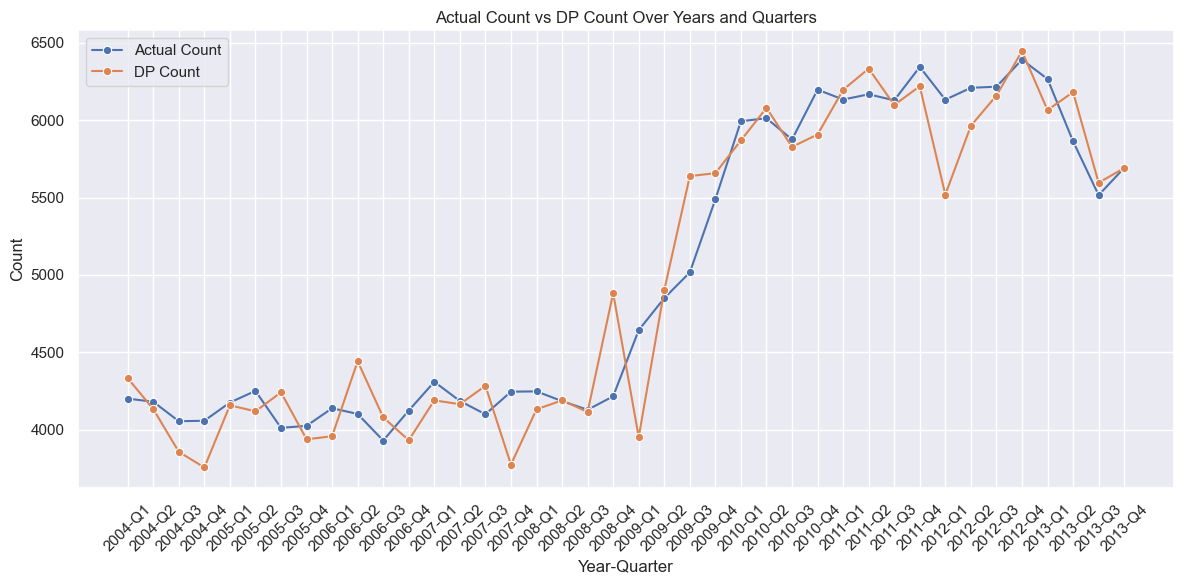

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(x=count_year_all["Year-Quarter"].to_list(), y=count_year_all['Actual Count'].to_list(), marker='o', label='Actual Count')
sns.lineplot(x=count_year_all["Year-Quarter"].to_list(), y=count_year_all['DP Count'].to_list(), marker='o', label='DP Count')

plt.title('Actual Count vs DP Count Over Years and Quarters')
plt.xlabel('Year-Quarter')
plt.ylabel('Count')
plt.xticks(rotation=45) 
plt.legend()

plt.grid(True)
plt.tight_layout()  
plt.show()

While the differentially private values still follow the general trend of the actual values, they do vary significantly more due to the smaller sizes of the year-quarter groups. 

### Caution Against Excessive Grouping

Larger data generally corresponds to less noise being added relative to the group size and higher utility. Excessive grouping by multiple keys can lead to smaller partitions. Adding noise to the smaller partitions may dilute the utility of the results, compared to adding noise for larger partitions. 

While grouping is an essential strategy for meaningful data analysis, there must be a balance as excessive grouping can lead to noisy and misleading results.

## Filtering

To demonstrate the `filter` method, compute the total number of respondents not working due to a layoff. 

In [11]:
filt_actual = (
    df.filter(pl.col("ILOSTAT")==3).select(
        pl.len()
    )
).collect().item()
print("Actual Total Count of Laid Off Respondents: ", filt_actual)

filt_dp = (
    context.query().filter(pl.col("ILOSTAT")==3).select(
        pl.len().dp.noise()
    )
).release().collect().item()
print("DP Total Count of Laid Off Respondents: ", filt_dp)

Actual Total Count of Laid Off Respondents:  76009
DP Total Count of Laid Off Respondents:  76251


Similar to partitioning, if the result of filtering is a smaller subset, it can lead to an increase in noise and a decrease in utility. 